# Chương 1. Tổng quan về Logic mờ và Ứng dụng

## 3. Tập hợp mờ (Fuzzy Logic)

### Ví dụ 1:
* Giả sử khi cần quản lý về tuổi để phân biệt **người trẻ tuổi**, **người trung niên** và **người già**.

* Ta sử dụng 3 tập tương ứng:
  **A:** trẻ, **B:** trung niên, **C:** già.

* **A, B, C** được gọi là 3 **tập mờ** khi tìm được 3 **hàm thuộc**
  tương ứng là μₐ, μ_b, μ_c.

* Giả sử **không gian nền** là
  **X = {1, 14, 25, 40, 60, 100}**, và quy ước rằng:

  * Người **trẻ tuổi** khi tuổi của họ xung quanh **25**.
  * Người **trung niên** thường có tuổi xấp xỉ **40**.
  * Còn khi **60 tuổi trở lên** có thể coi là **già**.


**Không gian nền**:

X={1,14,25,40,60,100}.

**Chọn ba tập mờ**:

* A – **Trẻ**: {(1,0),(14,0.6),(25,1),(40,0),(60,0),(100,0)}
* B – **Trung niên**: {(1,0),(14,0),(25,0.4),(40,1),(60,0.2),(100,0)}
* C – **Già**: {(1,0),(14,0),(25,0),(40,0.5),(60,1),(100,1)}

$$
A = 
\left\{
\frac{0}{1},
\frac{0.6}{14},
\frac{1}{25},
\frac{0}{40},
\frac{0}{60},
\frac{0}{100}
\right\}, \qquad
B =
\left\{
\frac{0}{1},
\frac{0}{14},
\frac{0.4}{25},
\frac{1}{40},
\frac{0.2}{60},
\frac{0}{100}
\right\}, \qquad

C =
\left\{
\frac{0}{1},
\frac{0}{14},
\frac{0}{25},
\frac{0.5}{40},
\frac{1}{60},
\frac{1}{100}
\right\}.
$$

**Bảng tổng hợp ($\mu_A$,$\mu_B$,$\mu_C$)**:

| x   | $\mu_A$ | $\mu_B$ | $\mu_C$ | Nhãn “hợp nhất” (argmax) |
| --- | --- | --- | --- | ------------------------ |
| 1   | 0   | 0   | 0   | — (không xác định)       |
| 14  | 0.6 | 0   | 0   | Trẻ                      |
| 25  | 1   | 0.4 | 0   | Trẻ                      |
| 40  | 0   | 1   | 0.5 | Trung niên               |
| 60  | 0   | 0.2 | 1   | Già                      |
| 100 | 0   | 0   | 1   | Già                      |


+ “Hợp nhất” ở đây là chọn nhãn có độ thuộc lớn nhất (nếu hòa, có thể cho “không xác định” hoặc áp dụng quy tắc ưu tiên).

**Diễn giải**:
* “Trẻ” tập trung quanh 25 nên điểm 25 có ($\mu_A=1$), còn 14 vẫn được xem là **khá trẻ** (0.6).
* “Trung niên” đỉnh ở 40 ($\mu_B=1$), nhưng 25 vẫn có mức **hơi trung niên** (0.4).
* “Già” đạt mức 1 từ 60 trở lên; tại 40 đã có mức **nửa-già** (0.5).


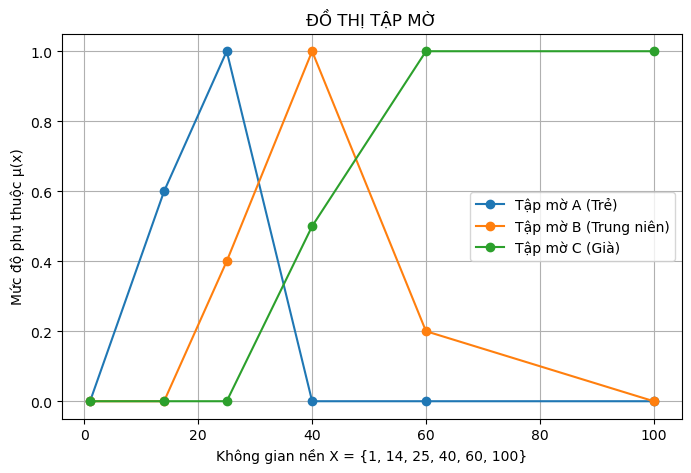

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Không gian nền
X = np.array([1, 14, 25, 40, 60, 100])

# Hàm thuộc theo bảng trong slide
mu_A = np.array([0, 0.6, 1, 0, 0, 0])   # Trẻ
mu_B = np.array([0, 0, 0.4, 1, 0.2, 0]) # Trung niên
mu_C = np.array([0, 0, 0, 0.5, 1, 1])   # Già

# Vẽ đồ thị
plt.figure(figsize=(8,5))
plt.plot(X, mu_A, marker='o', label='Tập mờ A (Trẻ)')
plt.plot(X, mu_B, marker='o', label='Tập mờ B (Trung niên)')
plt.plot(X, mu_C, marker='o', label='Tập mờ C (Già)')

plt.title("ĐỒ THỊ TẬP MỜ")
plt.xlabel("Không gian nền X = {1, 14, 25, 40, 60, 100}")
plt.ylabel("Mức độ phụ thuộc μ(x)")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True)
plt.show()


### Ví dụ 2:

* Trường hợp không gian nền là một tập hợp vô hạn không đếm được, thì **hàm thành viên** có thể biểu diễn bằng **một biểu thức**.

  * Chẳng hạn, với không gian nền **X** là độ tuổi được tính rất chi ly.
  * Khi đó, **hàm thành viên** của tập mờ tuổi trẻ **A** có thể nội suy các giá trị tại những điểm rời rạc nêu trên để trở thành **một hàm liên tục**.

* Để xấp xỉ các giá trị của **μₐ(x)**, với mọi
  
  $x ∈ [1,14], [14,25], [25,40], [40,100]$,
  
  ta có thể **nội suy tuyến tính** bằng một **đường thẳng** đi qua hai điểm.

* Giả sử hai điểm có tọa độ là **(xₚ, yₚ)** và **(x_Q, y_Q)**.

* Phương trình đường thẳng qua hai điểm:
$$
y = y_P + (y_Q - y_P) \frac{x - x_P}{x_Q - x_P}
$$


Viết **hàm thuộc liên tục** bằng nội suy tuyến tính qua các điểm đã cho. Kí hiệu công thức chung cho đường thẳng qua hai điểm $P(x_P,y_P)$, $Q(x_Q,y_Q)$:
$$
y(x)=y_P+,(y_Q-y_P),\frac{x-x_P}{x_Q-x_P}.
$$

**1.Tập mờ $A$ – “Trẻ”**

Các mốc: $(1,0) \to (14,0.6) \to (25,1) \to(40,0)$.

$$
\mu_A(x)=
\begin{cases}
0, & x\le 1, \\
\dfrac{0.6}{13}(x-1), & x\in[1,14),\\
0.6+\dfrac{1-0.6}{25-14}(x-14)=\dfrac{0.4}{11}x+\dfrac{1}{11}, & x\in[14,25), \\
1+\dfrac{0-1}{40-25}(x-25)=\dfrac{40-x}{15}, & x\in[25,40), \\
0, & x\in[40,100), \\
0, & x\ge 100. \\
\end{cases}
$$

**2.Tập mờ $B$ – “Trung niên”**

Các mốc: $(1,0) \to (14,0) \to (25,0.4) \to (40,1) \to (60,0.2) \to(100,0)$.

$$
\mu_B(x)=
\begin{cases}
0, & x\le 14, \\
\dfrac{0.4-0}{25-14}(x-14)=\dfrac{0.4}{11}(x-14), & x\in[14,25), \\
0.4+\dfrac{1-0.4}{40-25}(x-25)=0.4+\dfrac{1}{25}(x-25), & x\in[25,40),\\
1+\dfrac{0.2-1}{60-40}(x-40)=1-\dfrac{1}{25}(x-40), & x\in[40,60),\\
0.2+\dfrac{0-0.2}{100-60}(x-60)=0.2-\dfrac{1}{200}(x-60), & x\in[60,100),\\
0, & x\ge 100.\\
\end{cases}
$$

**3.Tập mờ $C$ – “Già”**

Các mốc: $(1,0) \to (14,0) \to (25,0) \to (40,0.5) \to(60,1) \to(100,1)$.

$$
\mu_C(x)=
\begin{cases}
0, & x\le 25,\\
\dfrac{0.5-0}{40-25}(x-25)=\dfrac{1}{30}(x-25), & x\in[25,40),\\
0.5+\dfrac{1-0.5}{60-40}(x-40)=0.5+\dfrac{1}{40}(x-40), & x\in[40,60),\\
1, & x\in[60,100),\\
1, & x\ge 100.
\end{cases}
$$

+ Các hàm trên đều là **nội suy tuyến tính** giữa các điểm mốc nên liên tục theo từng đoạn.

+ Có thể dùng để tính $\alpha-cut$, vẽ đồ thị, hay làm mờ / giải mờ.


### Bài tập 1:
#### Đề bài
* Cho **X** là không gian nền về kích thước phòng học căn cứ vào số lượng bàn ghế đủ cho sinh viên ngồi học.

* Chẳng hạn, có 8 phòng học với khả năng chứa là một phần tử của tập **X** như sau:
 
**X = {30, 50, 75, 90, 100, 125, 150, 200}**.
  
* Xây dựng các tập:

  * **A** là tập mờ các phòng học rộng.
  * **B** là tập mờ các phòng có thể chứa 100 sinh viên.
  * **C** là tập các phòng học không chứa quá 100 sinh viên.

#### Bài giải

**Không gian nền**:

X={30, 50, 75, 90, 100, 125, 150, 200}.

**Chọn ba tập mờ**:

* A – **Rộng**: {(30,0),(50,0),(75,0.25),(90,0.4),(100,0.5),(125,0.75),(150,1),(200,1)}
* B – **Có thể chứa 100 sinh viên**: {(30,0),(50,0),(75,0),(90,0),(100,1),(125,1),(150,1),(200,1)}
* C – **Không Chứa quá 100 sinh viên**: {(30,1),(50,1),(75,1),(90,1),(100,1),(125,0),(150,0),(200,0)}

$$
A = 
\left\{
\frac{0}{30},
\frac{0}{50},
\frac{0.25}{75},
\frac{0.40}{90},
\frac{0.50}{100},
\frac{0.75}{125},
\frac{1}{150},
\frac{1}{200}
\right\}, \qquad

B = 
\left\{
\frac{0}{30},
\frac{0}{50},
\frac{0}{75},
\frac{0}{90},
\frac{1}{100},
\frac{1}{125},
\frac{1}{150},
\frac{1}{200}
\right\}, \qquad

C = 
\left\{
\frac{1}{30},
\frac{1}{50},
\frac{1}{75},
\frac{1}{90},
\frac{1}{100},
\frac{0}{125},
\frac{0}{150},
\frac{0}{200}
\right\}, \qquad
$$

**Bảng tổng hợp ($\mu_A$,$\mu_B$,$\mu_C$)**:

| x   | $\mu_A$ | $\mu_B$ | $\mu_C$ | Nhãn “hợp nhất” (argmax) |
| --- | ----  | --- | --- | ------------------------ |
| 30  | 0     | 0   | 1   | Không chứa quá 100 sinh viên  |
| 50  | 0     | 0   | 1   | Không chứa quá 100 sinh viên  |
| 75  | 0.25  | 0   | 1   | Không chứa quá 100 sinh viên  |
| 90  | 0.40  | 0   | 1   | Không chứa quá 100 sinh viên  |
| 100 | 0.50  | 1   | 0   | Không chứa quá 100 sinh viên  |
| 125 | 0.75  | 1   | 0   | Không chứa quá 100 sinh viên  |
| 150 | 1     | 1   | 0   | Rộng và Có thể chứa 100 sinh viên  |
| 200 | 1     | 1   | 0   | Rộng và Có thể chứa 100 sinh viên  |


+ “Hợp nhất” ở đây là chọn nhãn có độ thuộc lớn nhất (nếu hòa, có thể cho “không xác định” hoặc áp dụng quy tắc ưu tiên).

**Diễn giải**:
* Tập mờ **A (Rộng)** tăng dần theo sức chứa: từ mức thấp ở 75 (0.25), 90 (0.40), 100 (0.50), 125 (0.75) và đạt tối đa ở 150, 200 ($\mu_A=1$).
* Tập mờ **B (Có thể chứa 100 sinh viên)** có mức thuộc bằng 0 ở các phòng nhỏ hơn 100, và bằng 1 từ 100 trở lên (100, 125, 150, 200).
* Tập mờ **C (Không chứa quá 100 sinh viên)** có mức thuộc bằng 1 ở các phòng 30, 50, 75, 90, 100 và bằng 0 với với các phòng có sức chứa lớn hơn 100 sinh viên.
* Theo cột **argmax**, các phòng 30–100 được gán nhãn *Không chứa quá 100 sinh viên*, và các phòng từ 100 trở lên được gán nhãn *Có thể chứa 100 sinh viên*.


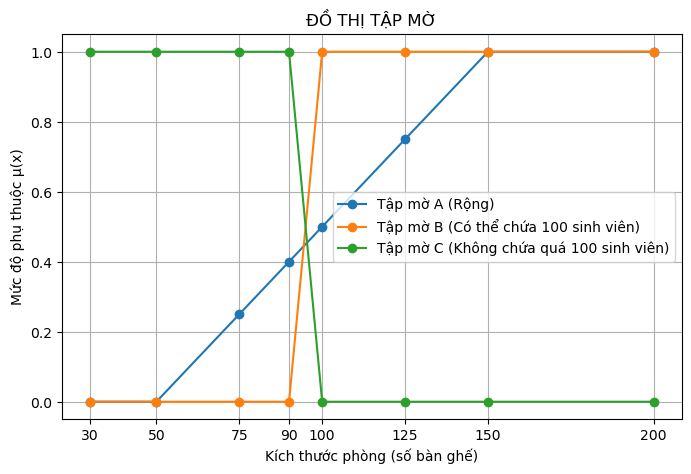

In [2]:
# Vẽ đồ thị tập mờ
import numpy as np
import matplotlib.pyplot as plt

# Không gian nền X={30, 50, 75, 90, 100, 125, 150, 200}.
X = np.array([30, 50, 75, 90, 100, 125, 150, 200])

# Hàm thuộc theo quy ước
mu_A = np.array([0, 0, 0.25, 0.4, 0.5, 0.75, 1, 1])   # Rộng
mu_B = np.array([0, 0, 0, 0, 1, 1, 1, 1])       # Có thể chứa 100 sinh viên
mu_C = np.array([1, 1, 1, 1, 0, 0, 0, 0])       # Không chứa quá 100 sinh viên

# Vẽ đồ thị
plt.figure(figsize=(8,5))
plt.plot(X, mu_A, marker='o', label='Tập mờ A (Rộng)')
plt.plot(X, mu_B, marker='o', label='Tập mờ B (Có thể chứa 100 sinh viên)')
plt.plot(X, mu_C, marker='o', label='Tập mờ C (Không chứa quá 100 sinh viên)')

plt.title("ĐỒ THỊ TẬP MỜ")
plt.xlabel("Kích thước phòng (số bàn ghế)")
plt.ylabel("Mức độ phụ thuộc μ(x)")
plt.xticks(X)  # Hiển thị tất cả nhãn giá trị trên trục X
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True)
plt.show()


* Trường hợp không gian nền là một tập hợp vô hạn không đếm được, thì **hàm thành viên** có thể biểu diễn bằng **một biểu thức**.

  * Chẳng hạn, với không gian nền **X** là kích thước phòng (số bàn ghế) được tính rất chi ly.
  * Khi đó, **hàm thành viên** của tập mờ phòng rộng **A** có thể nội suy các giá trị tại những điểm rời rạc nêu trên để trở thành **một hàm liên tục**.

* Để xấp xỉ các giá trị của **μₐ(x)**, với mọi
  
  $x ∈ [30,50], [50,75], [75,90], [90,100], [100,125], [125,150], [150,200]$,
  
  ta có thể **nội suy tuyến tính** bằng một **đường thẳng** đi qua hai điểm.

* Giả sử hai điểm có tọa độ là **(xₚ, yₚ)** và **(x_Q, y_Q)**.

* Phương trình đường thẳng qua hai điểm:
$$
y = y_P + (y_Q - y_P) \frac{x - x_P}{x_Q - x_P}
$$

Viết **hàm thuộc liên tục** bằng nội suy tuyến tính qua các điểm đã cho. Kí hiệu công thức chung cho đường thẳng qua hai điểm $P(x_P,y_P)$, $Q(x_Q,y_Q)$:
$$
y(x)=y_P+(y_Q-y_P)\frac{x-x_P}{x_Q-x_P}.
$$

**1.Tập mờ $A$ – “Rộng”**

Với các mốc: $(50,0) \to (75,0.25) \to (90,0.40) \to (100,0.5) \to (125,0.75) \to (150,1)$

$$
\mu_A(x)=
\begin{cases}
0, & x\le 50, \\[6pt]
0.01(x-50), & 50 < x \le 75, \\[6pt]
0.25+0.01(x-75), & 75 < x \le 90, \\[6pt]
0.40+0.01(x-90), & 90 < x \le 100, \\[6pt]
0.5+0.01(x-100), & 100 < x \le 125, \\[6pt]
0.75+0.01(x-125), & 125 < x \le 150, \\[6pt]
1, & x>150.
\end{cases}
$$

**2.Tập mờ $B$ – “Có thể chứa 100 sinh viên”**

Với các mốc:$(90,0) \to (100,1)$

$$
\mu_B(x)=
\begin{cases}
0, & x\le 90, \\[6pt]
\dfrac{x-90}{10}, & 90 < x < 100, \\[6pt]
1, & x\ge 100.
\end{cases}
$$

**3.Tập mờ $C$ – “Không chứa quá 100 sinh viên”**

Với các mốc: $(100,1) \to (125,0)$

$$
\mu_C(x)=
\begin{cases}
1, & x\le 100, \\[6pt]
\dfrac{125-x}{25}, & 100 \lt x \lt 125, \\[6pt]
0, & x\ge 125.
\end{cases}
$$


### Bài 5

#### Đề bài

Độ pH tiêu chuẩn của nước uống nên nằm trong khoảng 6 đến 8.5. Hãy vẽ hàm thuộc hợp lý cho chất lượng nước uống, với giá trị pH tối ưu trên thang đo từ 0–14.

#### Bài giải

Gọi \(x\) là giá trị pH của nước: $x \in [0,14]$

Độ pH tiêu chuẩn của nước uống nằm trong khoảng: $6 \le x \le 8.5$

$$
\mu_{\text{drinkable}}(x)=
\begin{cases}
0, & x \le 5.5 \\\\
\dfrac{x-5.5}{0.5}, & 5.5 < x < 6 \\\\
1, & 6 \le x \le 8.5 \\\\
\dfrac{9-x}{0.5}, & 8.5 < x < 9 \\\\
0, & x \ge 9
\end{cases}
$$

Rút gọn:

$$
\mu_{\text{drinkable}}(x)=
\begin{cases}
0, & x \le 5.5 \\\\
2(x-5.5), & 5.5 < x < 6 \\\\
1, & 6 \le x \le 8.5 \\\\
2(9-x), & 8.5 < x < 9 \\\\
0, & x \ge 9
\end{cases}
$$

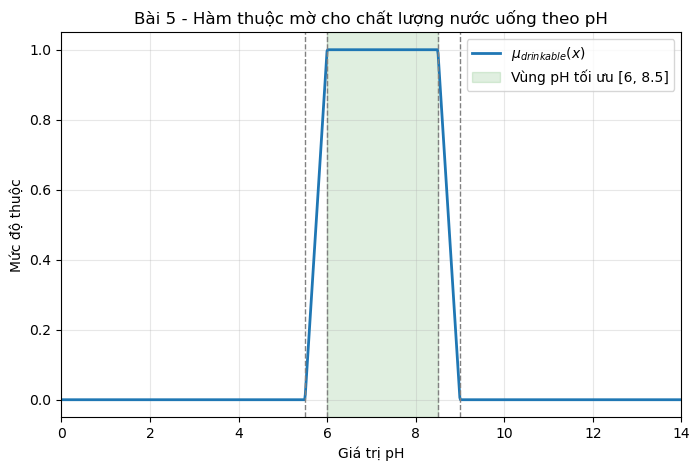

In [3]:
# Bài 5: Minh hoạ hàm thuộc chất lượng nước uống theo pH

x = np.linspace(0, 14, 1000)

# Hàm thuộc mờ cho chất lượng nước uống theo pH:
# - 0 khi pH <= 5.5 hoặc pH >= 9
# - Tăng tuyến tính từ 0 -> 1 trên (5.5, 6)
# - Giữ mức 1 trên [6, 8.5]
# - Giảm tuyến tính từ 1 -> 0 trên (8.5, 9)
mu_drinkable = np.piecewise(
    x,
    [
        x <= 5.5,               # Quá a-xit: không đạt
        (x > 5.5) & (x < 6),    # Vùng chuyển tiếp tăng
        (x >= 6) & (x <= 8.5),  # Vùng tối ưu
        (x > 8.5) & (x < 9),    # Vùng chuyển tiếp giảm
        x >= 9                  # Quá kiềm: không đạt
    ],
    [
        0,
        lambda x: 2 * (x - 5.5),
        1,
        lambda x: 2 * (9 - x),
        0
    ]
)

plt.figure(figsize=(8, 5))
plt.plot(x, mu_drinkable, color="tab:blue", linewidth=2, label=r'$\mu_{drinkable}(x)$')
plt.axvspan(6, 8.5, color="green", alpha=0.12, label='Vùng pH tối ưu [6, 8.5]')
plt.axvline(5.5, color="gray", linestyle="--", linewidth=1)
plt.axvline(6, color="gray", linestyle="--", linewidth=1)
plt.axvline(8.5, color="gray", linestyle="--", linewidth=1)
plt.axvline(9, color="gray", linestyle="--", linewidth=1)

plt.title("Bài 5 - Hàm thuộc mờ cho chất lượng nước uống theo pH")
plt.xlabel("Giá trị pH")
plt.ylabel("Mức độ thuộc")
plt.xlim(0, 14)
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### Bài 6

#### Đề bài

Để phát điện, tua-bin phải quay “ít nhất \(40\) vòng/phút (rpm)”. Hãy vẽ hàm thuộc mô tả ảnh hưởng của tốc độ quay lên khả năng phát điện, sử dụng:

- Hàm thuộc rõ ràng (crisp)
- Hàm thuộc mờ (fuzzy)

#### Bài giải

Gọi \(x\) là tốc độ quay của tua-bin: $x \ge 0$

Điều kiện phát điện: $x \ge 40 \text{ rpm}$

 **a. Hàm thuộc rõ ràng (crisp)**

$$
\mu_{\text{crisp}}(x)=
\begin{cases}
0, & x < 40 \\\\
1, & x \ge 40
\end{cases}
$$

### b. Hàm thuộc mờ (fuzzy)

Chọn vùng chuyển tiếp từ \(40\) rpm đến \(50\) rpm:

$$
\mu_{\text{fuzzy}}(x)=
\begin{cases}
0, & x \lt 40 \\\\
\dfrac{x-40}{10}, & 40 \le x \lt 50 \\\\
1, & x \ge 50
\end{cases}
$$

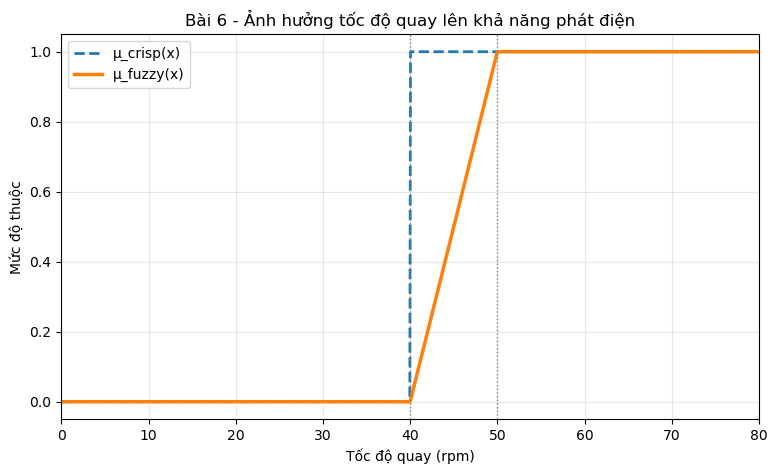

In [4]:
# Bài 6: Minh hoạ hàm thuộc crisp và fuzzy cho tốc độ tua-bin phát điện

x = np.linspace(0, 80, 1000)

# Hàm crisp: phát điện khi x >= 40
mu_crisp = np.where(x < 40, 0, 1)

# Hàm fuzzy: chuyển tiếp từ 40 đến 50 rpm
mu_fuzzy = np.piecewise(
    x,
    [x < 40, (x >= 40) & (x < 50), x >= 50],
    [0, lambda t: (t - 40) / 10, 1]
)

plt.figure(figsize=(9, 5))
plt.plot(x, mu_crisp, linestyle='--', linewidth=2, label='μ_crisp(x)')
plt.plot(x, mu_fuzzy, linewidth=2.5, label='μ_fuzzy(x)')
plt.axvline(40, color='gray', linestyle=':', linewidth=1)
plt.axvline(50, color='gray', linestyle=':', linewidth=1)

plt.title("Bài 6 - Ảnh hưởng tốc độ quay lên khả năng phát điện")
plt.xlabel("Tốc độ quay (rpm)")
plt.ylabel("Mức độ thuộc")
plt.xlim(0, 80)
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

<!-- Với các mốc:
Viết **hàm thuộc liên tục** bằng nội suy tuyến tính qua các điểm đã cho. Kí hiệu công thức chung cho đường thẳng qua hai điểm $P(x_P,y_P)$, $Q(x_Q,y_Q)$:
$$
y(x)=y_P+,(y_Q-y_P),\frac{x-x_P}{x_Q-x_P}.
$$

**1.Tập mờ $A$ – “Rộng”**

Các mốc: 
$$
(50,0) \to (75,0.25) \to (90,0.40) \to (100,0.5) \to (125,0.75) \to (150,1)
$$

$$
\mu_A(x)=
\begin{cases}
0, & x\le 50, \\[6pt]
0.01(x-50), & 50 < x \le 75, \\[6pt]
0.25+0.01(x-75), & 75 < x \le 90, \\[6pt]
0.40+0.01(x-90), & 90 < x \le 100, \\[6pt]
0.5+0.01(x-100), & 100 < x \le 125, \\[6pt]
0.75+0.01(x-125), & 125 < x \le 150, \\[6pt]
1, & x>150.
\end{cases}
$$

$$
\mu_B(x)=
\begin{cases}
0, & x<100, \\[6pt]
1, & x>100.
\end{cases}
$$ -->


### Bài 7

#### Đề bài

Theo định luật Hooke, trong giới hạn đàn hồi, ứng suất tỉ lệ thuận với biến dạng. Thép mềm (mild steel) có tính chất này đến giới hạn ứng suất $335 \text{ MPa}$. Hãy vẽ cả hàm thuộc rõ ràng và hàm thuộc mờ cho phát biểu: “Thép mềm vẫn nằm trong giới hạn đàn hồi”.

#### Bài giải

Gọi \(x\) là ứng suất của thép mềm: $x \ge 0$

Giới hạn đàn hồi: $x \le 335 \text{ MPa}$

**a. Hàm thuộc rõ ràng (crisp)**

$$
\mu_{\text{crisp}}(x)=
\begin{cases}
1, & x \le 335 \\\\
0, & x > 335
\end{cases}
$$

**b. Hàm thuộc mờ (fuzzy)**

Chọn vùng chuyển tiếp từ $300\text{ MPa}$ đến $370\text{ MPa}$:

$$
\mu_{\text{fuzzy}}(x)=
\begin{cases}
1, & x \le 300 \\\\
\dfrac{370-x}{70}, & 300 \lt x \le 370 \\\\
0, & x \gt 370
\end{cases}
$$



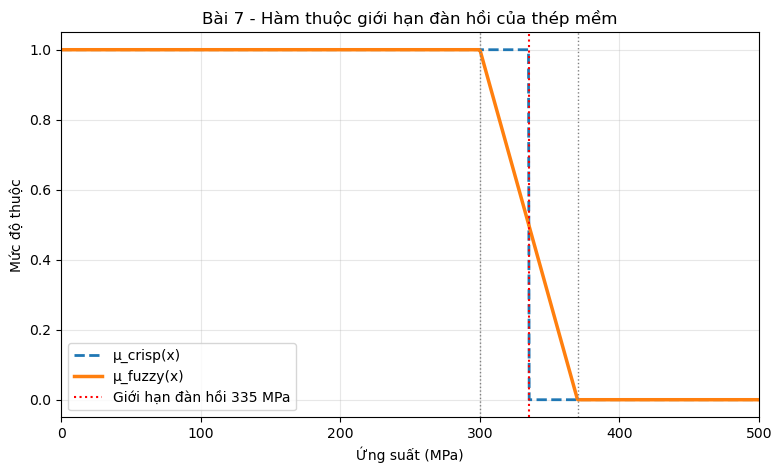

In [5]:
# Bài 7: Minh hoạ hàm thuộc crisp và fuzzy cho giới hạn đàn hồi thép mềm

x_stress = np.linspace(0, 500, 1000)

# Hàm crisp: trong giới hạn đàn hồi khi x <= 335 MPa
mu_crisp_steel = np.where(x_stress <= 335, 1, 0)

# Hàm fuzzy: chuyển tiếp từ 300 đến 370 MPa
mu_fuzzy_steel = np.piecewise(
    x_stress,
    [x_stress <= 300, (x_stress > 300) & (x_stress <= 370), x_stress > 370],
    [1, lambda t: (370 - t) / 70, 0]
)

plt.figure(figsize=(9, 5))
plt.plot(x_stress, mu_crisp_steel, linestyle='--', linewidth=2, label='μ_crisp(x)')
plt.plot(x_stress, mu_fuzzy_steel, linewidth=2.5, label='μ_fuzzy(x)')
plt.axvline(335, color='red', linestyle=':', linewidth=1.5, label='Giới hạn đàn hồi 335 MPa')
plt.axvline(300, color='gray', linestyle=':', linewidth=1)
plt.axvline(370, color='gray', linestyle=':', linewidth=1)

plt.title("Bài 7 - Hàm thuộc giới hạn đàn hồi của thép mềm")
plt.xlabel("Ứng suất (MPa)")
plt.ylabel("Mức độ thuộc")
plt.xlim(0, 500)
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Kết thúc